In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
import math
import re

In [2]:
# Determine the absolute path to the src directory (one level up from notebooks)
module_path = os.path.abspath(os.path.join("..", "src"))
if module_path not in sys.path:
    sys.path.append(module_path)
import plotting
import utils

In [3]:
ROOT_FOLDER = os.path.dirname(os.getcwd())
RUNS_FOLDER = os.path.join(ROOT_FOLDER, "runs")
SINGLE_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "single_runs")
BATCH_RUNS_FOLDER = os.path.join(RUNS_FOLDER, "batch_runs")
TEST_BATCH_RUNS_FOLDER = os.path.join(BATCH_RUNS_FOLDER, "test")

In [ ]:
batch_name = "37_2_4_8_16_32_monday"
batch_folder = os.path.join(BATCH_RUNS_FOLDER, batch_name)
folders = [os.path.join(batch_folder, folder) for folder in os.listdir(batch_folder)]
names = [
    "2",
    "4",
    "8",
    "16",
    "32"
]

In [5]:
folders

['c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\37_2_4_8_16_32_monday\\1_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\37_2_4_8_16_32_monday\\2_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\37_2_4_8_16_32_monday\\3_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\37_2_4_8_16_32_monday\\4_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT',
 'c:\\Users\\tinus\\OneDrive\\Dokumenter\\0 Master\\code\\master_project\\runs\\batch_runs\\37_2_4_8_16_32_monday\\5_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT']

In [6]:
for root, dirs, files in os.walk(batch_folder):
    print(f"Currently in: {root}")
    print(f"Directories: {dirs}")
    print(f"Files: {files}\n")

Currently in: c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\37_2_4_8_16_32_monday
Directories: ['1_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT', '2_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT', '3_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT', '4_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT', '5_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT']
Files: []

Currently in: c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\37_2_4_8_16_32_monday\1_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT
Directories: ['decision_variables', 'model_info']
Files: []

Currently in: c:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\runs\batch_runs\37_2_4_8_16_32_monday\1_Mar31_Mon_h15-GTSEP_v1a_multi-37_ES_PT\decision_variables
Directories: []
Files: ['battery_capacity.csv', 'battery_charging.csv', 'battery_discharging.csv', 'battery_soc.csv', 'branch_capacity.csv', 'curtailment.csv', 'generation.csv', 'generator_capacity.csv', 'load_shedding.csv', 'power_flow.csv']

C

In [7]:
decision_variables = utils.load_csv_files_from_folder(
    os.path.join(folders[0], "decision_variables")
)
decision_variables["battery_charging"]

,week,hour,battery,value
year,,,,
2025,21,0,ES1 0 bat,0.0
2025,21,1,ES1 0 bat,0.0
2025,21,2,ES1 0 bat,0.0
2025,21,3,ES1 0 bat,0.0
2025,21,4,ES1 0 bat,0.0
...,...,...,...,...
2045,42,163,PT1 0 bat,0.0
2045,42,164,PT1 0 bat,0.0
2045,42,165,PT1 0 bat,0.0


In [8]:
import pandas as pd
from pathlib import Path


def read_decision_variables(folder_path):
    folder_path = Path(folder_path)
    decision_vars_path = folder_path / "decision_variables"

    dfs = {}

    # Files with 3 columns (year, index, value)
    files_3cols = [
        "battery_capacity.csv",
        "branch_capacity.csv",
        "generator_capacity.csv",
    ]
    for file in files_3cols:
        file_path = decision_vars_path / file
        df = pd.read_csv(file_path)
        df.set_index([df.columns[0], df.columns[1]], inplace=True)
        df.index.names = ["year", "index"]
        df.rename(columns={df.columns[-1]: "value"}, inplace=True)
        dfs[file.replace(".csv", "")] = df

    # Other files with 5 columns (year, week, hour, index, value)
    files_5cols = [
        f.name for f in decision_vars_path.glob("*.csv") if f.name not in files_3cols
    ]
    for file in files_5cols:
        file_path = decision_vars_path / file
        df = pd.read_csv(file_path)
        df.set_index(
            [df.columns[0], df.columns[1], df.columns[2], df.columns[3]], inplace=True
        )
        df.index.names = ["year", "week", "hour", "index"]
        df.rename(columns={df.columns[-1]: "value"}, inplace=True)
        dfs[file.replace(".csv", "")] = df

    return dfs


def load_all_batches(batch_folder_path):
    batch_folder = Path(batch_folder_path)
    results = {}
    for subfolder in sorted(batch_folder.iterdir()):
        if subfolder.is_dir():
            batch_name = subfolder.name
            results[batch_name] = read_decision_variables(subfolder)
    return results

In [9]:
all_decision_variables = load_all_batches(batch_folder)

In [10]:
all_decision_variables = {
    new_name: all_decision_variables[old_name]
    for new_name, old_name in zip(names, all_decision_variables.keys())
}

In [11]:
generators = pd.read_csv(
    r"C:\Users\tinus\OneDrive\Dokumenter\0 Master\code\master_project\data\processed\elec_s_37_ES_PT_no_bat_limit\generators.csv",
    index_col=0,
)
generators

,bus,carrier,p_nom,marginal_cost,capital_cost,co2_emissions,color,nice_name
generator,,,,,,,,
ES1 0 CCGT,ES1 0,CCGT,26305.332000,40.772380,99027.729293,0.20,#b20101,Combined-Cycle Gas
ES1 0 coal,ES1 0,coal,4739.393483,28.196970,349976.553630,0.34,#707070,Coal
ES1 0 offwind-ac,ES1 0,offwind-ac,9274.463486,0.015000,184160.119456,0.00,#6895dd,Offshore Wind (AC)
ES1 0 onwind,ES1 0,onwind,26825.862669,0.015000,96085.888020,0.00,#235ebc,Onshore Wind
ES1 0 ror,ES1 0,ror,147.008247,0.000000,299140.224929,0.00,#4adbc8,Run of River
ES1 0 solar,ES1 0,solar,11681.579273,0.010000,35602.071244,0.00,#f9d002,Solar
PT1 0 CCGT,PT1 0,CCGT,4145.000000,38.876697,99027.729293,0.20,#b20101,Combined-Cycle Gas
PT1 0 offwind-ac,PT1 0,offwind-ac,4460.188736,0.015000,185034.009941,0.00,#6895dd,Offshore Wind (AC)
PT1 0 onwind,PT1 0,onwind,5213.640675,0.015000,96085.888020,0.00,#235ebc,Onshore Wind


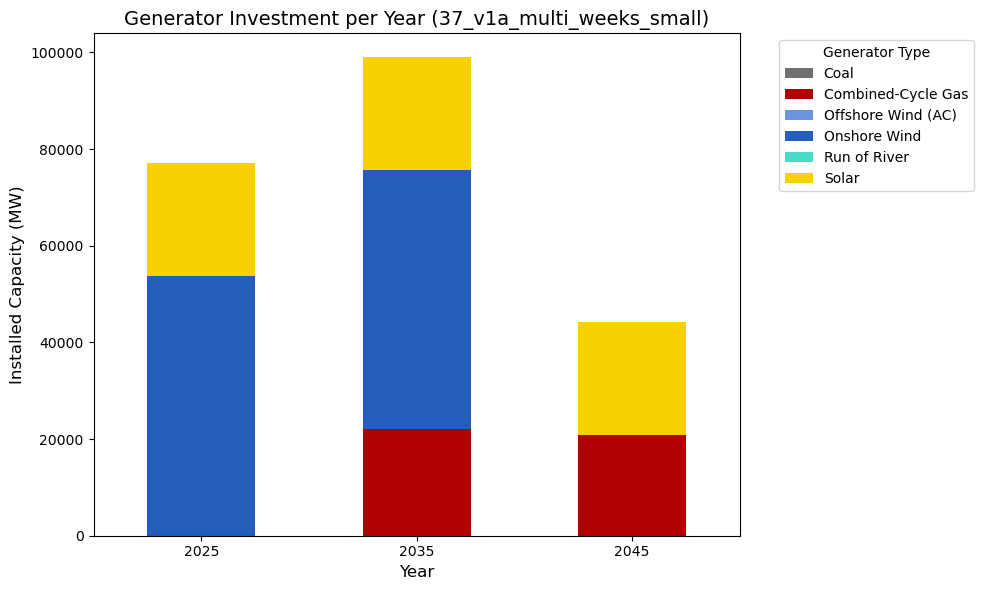

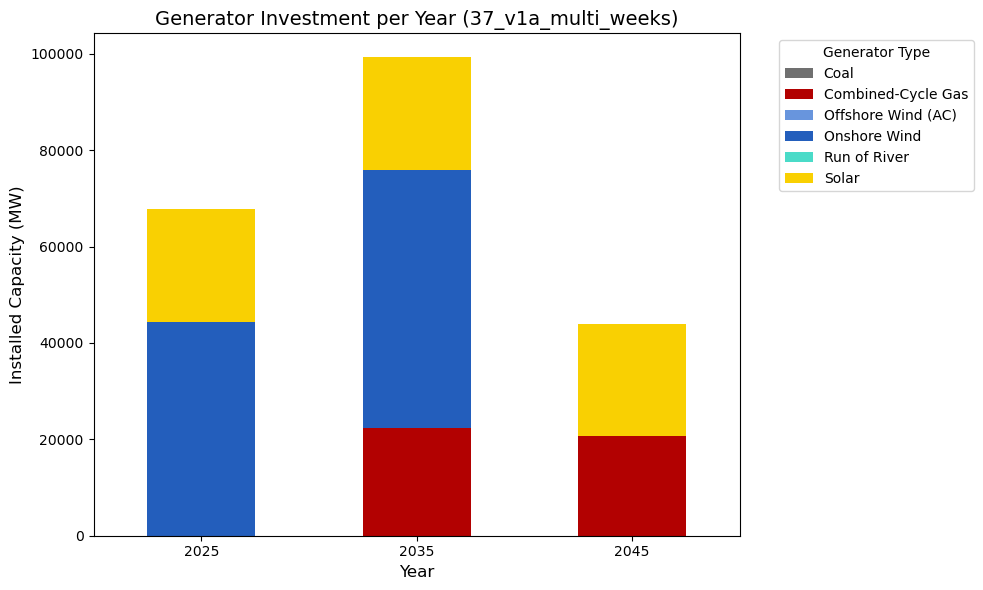

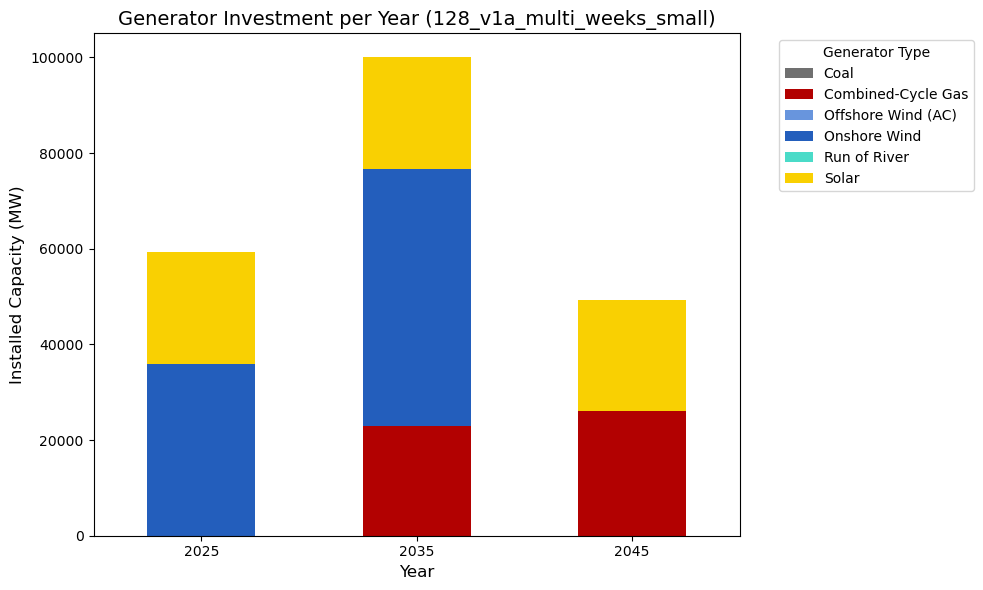

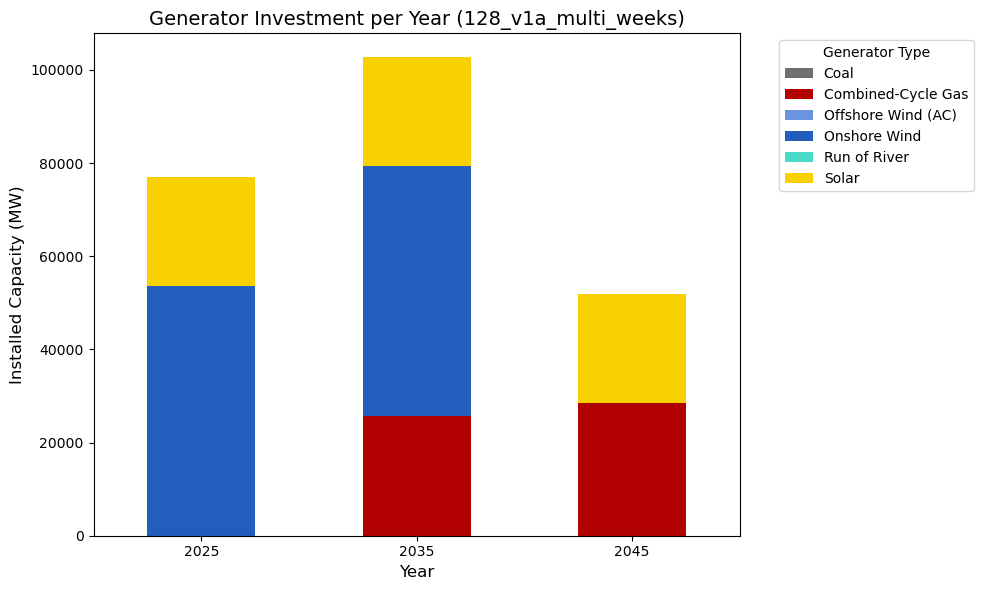

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


# Function to plot investment by generator type for each scenario
def plot_generator_investment(all_decision_variables, generators, scenario_names):
    carriers = generators[["carrier", "nice_name", "color"]].drop_duplicates()

    for scenario in scenario_names:
        gen_capacity_df = all_decision_variables[scenario][
            "generator_capacity"
        ].reset_index()

        # Map the index to carrier types and nice names
        gen_capacity_df["generator"] = gen_capacity_df["index"].apply(
            lambda x: " ".join(x.split(" ")[:3])
        )
        gen_capacity_df = gen_capacity_df.merge(
            carriers, left_on="generator", right_index=True, how="left"
        )

        # Group by year and nice_name
        grouped_df = (
            gen_capacity_df.groupby(["year", "nice_name", "color"])
            .agg({"value": "sum"})
            .reset_index()
        )

        # Pivot table for plotting
        pivot_df = grouped_df.pivot_table(
            index="year", columns="nice_name", values="value", fill_value=0
        )

        # Plotting
        ax = pivot_df.plot(
            kind="bar",
            stacked=True,
            figsize=(10, 6),
            color=[
                carriers.set_index("nice_name").loc[col, "color"]
                for col in pivot_df.columns
            ],
        )

        ax.set_title(f"Generator Investment per Year ({scenario})", fontsize=14)
        ax.set_xlabel("Year", fontsize=12)
        ax.set_ylabel("Installed Capacity (MW)", fontsize=12)
        plt.legend(title="Generator Type", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()


# Example usage:
scenario_names = [
    "37_v1a_multi_weeks_small",
    "37_v1a_multi_weeks",
    "128_v1a_multi_weeks_small",
    "128_v1a_multi_weeks",
]

plot_generator_investment(all_decision_variables, generators, scenario_names)

In [13]:
def plot_grouped_generator_investment(
    all_decision_variables, generators, scenario_names
):
    carriers = generators[["carrier", "nice_name", "color"]].drop_duplicates()

    combined_df = []
    for scenario in scenario_names:
        df = all_decision_variables[scenario]["generator_capacity"].reset_index()
        df["generator"] = df["index"].apply(lambda x: " ".join(x.split(" ")[:3]))
        df = df.merge(carriers, left_on="generator", right_index=True, how="left")
        df_grouped = df.groupby(["year", "nice_name", "color"], as_index=False)[
            "value"
        ].sum()
        df_grouped["scenario"] = scenario
        combined_df.append(df_grouped)

    combined_df = pd.concat(combined_df, ignore_index=True)

    # Unique years and scenarios
    years = sorted(combined_df["year"].unique())
    n_years = len(years)
    n_scenarios = len(scenario_names)

    # Adjust plot setup
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.8 / n_scenarios

    # Create explicit positions for every scenario within every year
    x = np.arange(n_years * n_scenarios)
    positions = []
    labels = []

    # Build positions and labels for each scenario within each year
    for year_idx, year in enumerate(years):
        for scenario_idx, scenario in enumerate(scenario_names):
            positions.append(year_idx * (n_scenarios + 1) + scenario_idx)
            labels.append(f"{year}\n({scenario_idx+1})")

    # Plot each bar
    for i, scenario in enumerate(scenario_names):
        scenario_df = combined_df[combined_df["scenario"] == scenario]
        pivot_df = scenario_df.pivot(
            index="year", columns="nice_name", values="value"
        ).fillna(0)

        bottom = np.zeros(n_years)
        for carrier in pivot_df.columns:
            values = pivot_df[carrier].reindex(years).fillna(0).values
            bar_positions = [
                year_idx * (n_scenarios + 1) + i for year_idx in range(n_years)
            ]
            ax.bar(
                bar_positions,
                values,
                bar_width,
                bottom=bottom,
                label=carrier if (i == 0) else "",
                color=carriers.set_index("nice_name").loc[carrier, "color"],
            )
            bottom += values

    # Set xticks explicitly
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=10)

    # Add clear separation between years
    ax.set_xlabel("Year (Scenario Number)", fontsize=12)
    ax.set_ylabel("Installed Capacity (MW)", fontsize=12)
    ax.set_title(
        "Generator Investment Comparison Across Scenarios and Years", fontsize=14
    )

    # Add a legend for scenario numbering clearly outside the plot
    scenario_legend = "\n".join(
        [f"{i+1}: {name}" for i, name in enumerate(scenario_names)]
    )
    plt.gcf().text(
        0.99,
        0.01,
        scenario_legend,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    )

    ax.legend(title="Generator Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    plt.show()

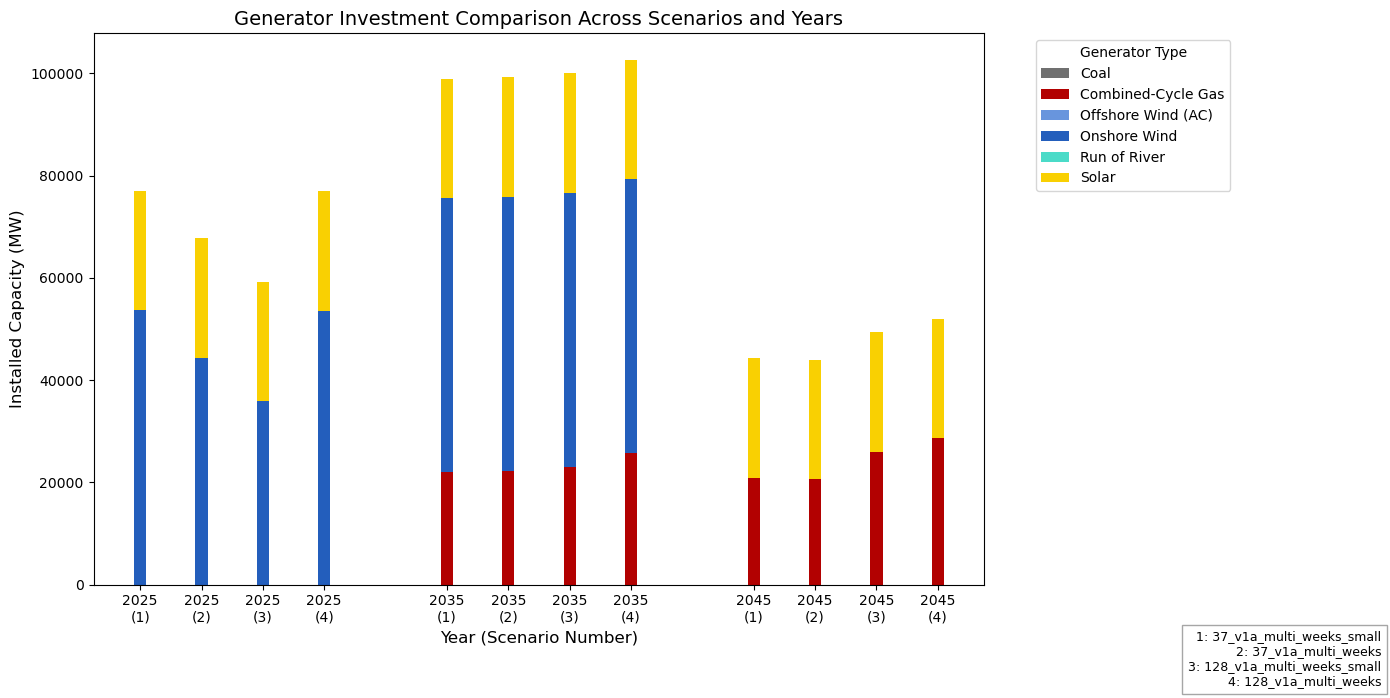

In [14]:
plot_grouped_generator_investment(all_decision_variables, generators, names)

In [15]:
def plot_grouped_battery_investment(all_decision_variables, scenario_names):
    combined_df = []
    for scenario in scenario_names:
        df = all_decision_variables[scenario]["battery_capacity"].reset_index()
        df_grouped = df.groupby("year", as_index=False)["value"].sum()
        df_grouped["scenario"] = scenario
        combined_df.append(df_grouped)

    combined_df = pd.concat(combined_df, ignore_index=True)

    # Unique years and scenarios
    years = sorted(combined_df["year"].unique())
    n_years = len(years)
    n_scenarios = len(scenario_names)

    # Explicit x-positions and labels for clarity
    positions = []
    labels = []

    for year_idx, year in enumerate(years):
        for scenario_idx, scenario in enumerate(scenario_names):
            positions.append(year_idx * (n_scenarios + 1) + scenario_idx)
            labels.append(f"{year}\n({scenario_idx+1})")

    # Plot setup
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.8

    # Plot each bar
    for i, scenario in enumerate(scenario_names):
        scenario_df = combined_df[combined_df["scenario"] == scenario]
        scenario_values = (
            scenario_df.set_index("year").reindex(years)["value"].fillna(0)
        )

        bar_positions = [
            year_idx * (n_scenarios + 1) + i for year_idx in range(n_years)
        ]
        ax.bar(
            bar_positions,
            scenario_values,
            bar_width,
            label=f"Scenario {i+1}",
            alpha=0.75,
        )

    # Set xticks explicitly
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=10)

    # Set labels and formatting
    ax.set_xlabel("Year (Scenario Number)", fontsize=12)
    ax.set_ylabel("Installed Battery Capacity (MW)", fontsize=12)
    ax.set_title(
        "Battery Investment Comparison Across Scenarios and Years", fontsize=14
    )

    # Scenario legend
    scenario_legend = "\n".join(
        [f"{i+1}: {name}" for i, name in enumerate(scenario_names)]
    )
    plt.gcf().text(
        0.99,
        0.01,
        scenario_legend,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    )

    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    plt.show()

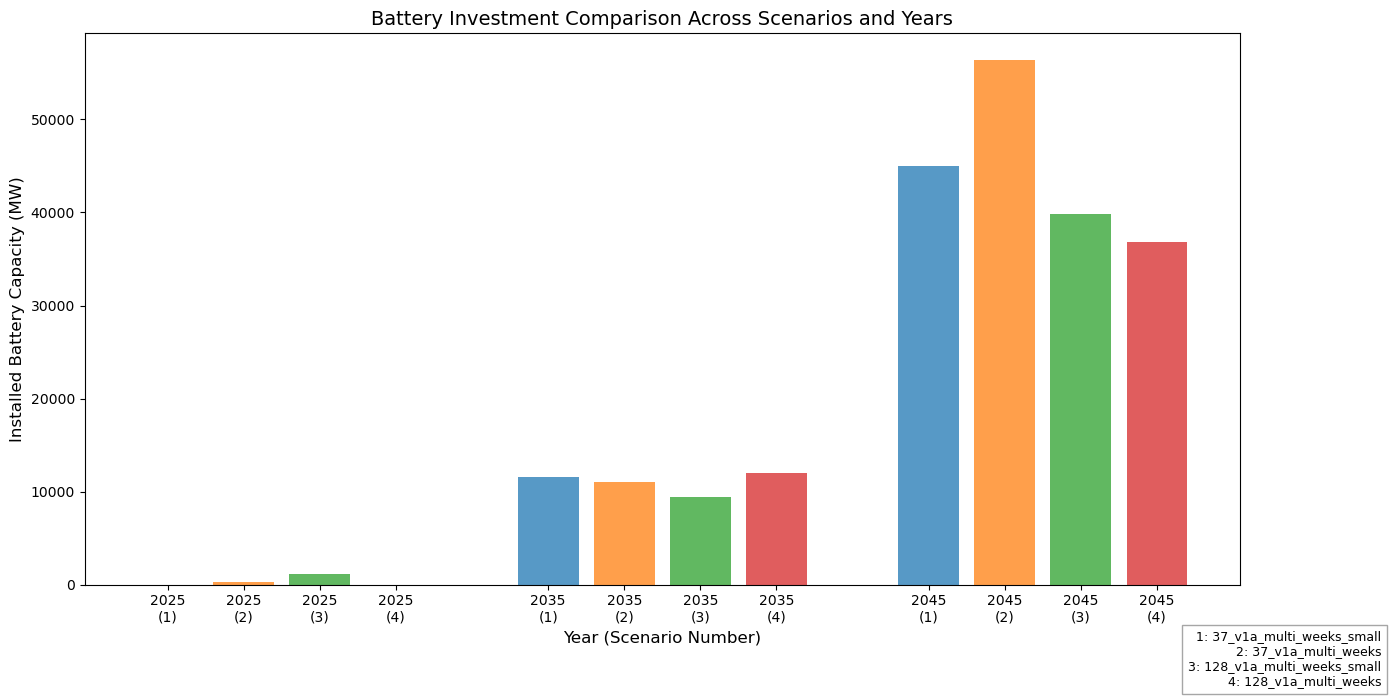

In [16]:
plot_grouped_battery_investment(all_decision_variables, names)

In [17]:
def plot_grouped_transmission_investment(all_decision_variables, scenario_names):
    combined_df = []
    for scenario in scenario_names:
        df = all_decision_variables[scenario]["branch_capacity"].reset_index()
        df_grouped = df.groupby("year", as_index=False)["value"].sum()
        df_grouped["scenario"] = scenario
        combined_df.append(df_grouped)

    combined_df = pd.concat(combined_df, ignore_index=True)

    # Unique years and scenarios
    years = sorted(combined_df["year"].unique())
    n_years = len(years)
    n_scenarios = len(scenario_names)

    # Explicit x-positions and labels for clarity
    positions = []
    labels = []

    for year_idx, year in enumerate(years):
        for scenario_idx, scenario in enumerate(scenario_names):
            positions.append(year_idx * (n_scenarios + 1) + scenario_idx)
            labels.append(f"{year}\n({scenario_idx+1})")

    # Plot setup
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.8

    # Plot each bar
    for i, scenario in enumerate(scenario_names):
        scenario_df = combined_df[combined_df["scenario"] == scenario]
        scenario_values = (
            scenario_df.set_index("year").reindex(years)["value"].fillna(0)
        )

        bar_positions = [
            year_idx * (n_scenarios + 1) + i for year_idx in range(n_years)
        ]
        ax.bar(
            bar_positions,
            scenario_values,
            bar_width,
            label=f"Scenario {i+1}",
            alpha=0.75,
            color=f"C{i}",
        )

    # Set xticks explicitly
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=10)

    # Set labels and formatting
    ax.set_xlabel("Year (Scenario Number)", fontsize=12)
    ax.set_ylabel("Installed Transmission Capacity (MW)", fontsize=12)
    ax.set_title(
        "Transmission Line Investment Comparison Across Scenarios and Years",
        fontsize=14,
    )

    # Scenario legend
    scenario_legend = "\n".join(
        [f"{i+1}: {name}" for i, name in enumerate(scenario_names)]
    )
    plt.gcf().text(
        0.99,
        0.01,
        scenario_legend,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    )

    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    plt.show()

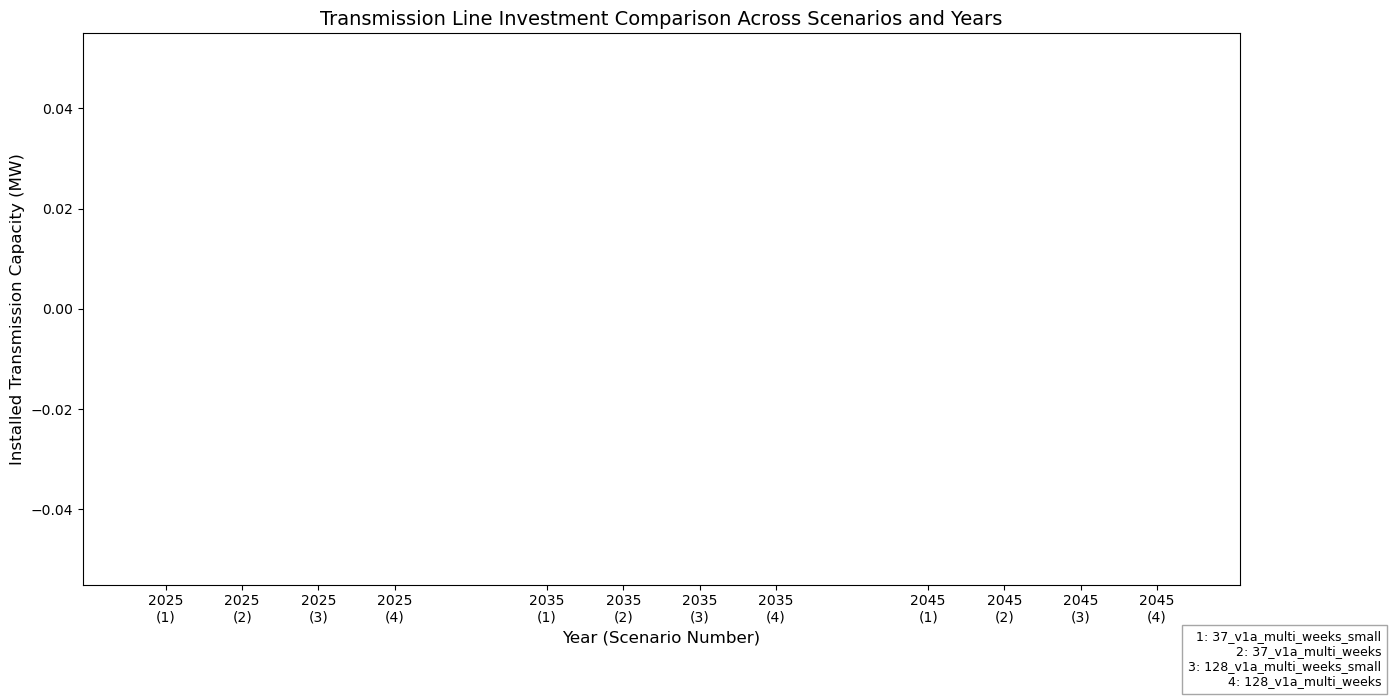

In [18]:
plot_grouped_transmission_investment(all_decision_variables, names)

In [19]:
import pandas as pd


def convert_to_datetime_index(df):
    df = df.reset_index()

    # Create base datetime from ISO week and year (Monday as the first day of week)
    base_dates = pd.to_datetime(
        df["year"].astype(str) + df["week"].astype(str).str.zfill(2) + "1",
        format="%G%V%u",
    )

    # Add hours to base dates (hour: 0–167 within week)
    df["datetime"] = base_dates + pd.to_timedelta(df["hour"], unit="h")

    # Set multi-index (datetime, index)
    df.set_index(["datetime", "index"], inplace=True)

    # Drop old indexing columns
    df.drop(columns=["year", "week", "hour"], inplace=True)

    return df

In [20]:
# Convert all relevant decision_variable DataFrames in the dictionary
for scenario, dataframes in all_decision_variables.items():
    for df_name, df in dataframes.items():
        # Only convert DataFrames with the (year, week, hour, index) format
        if all(index in df.index.names for index in ["year", "week", "hour"]):
            all_decision_variables[scenario][df_name] = convert_to_datetime_index(df)

In [21]:
all_decision_variables["37_v1a_multi_weeks"]["battery_soc"]

,,value
datetime,index,
2025-03-10 00:00:00,ES1 0 bat,0.000000
2025-03-10 01:00:00,ES1 0 bat,0.000000
2025-03-10 02:00:00,ES1 0 bat,0.000000
2025-03-10 03:00:00,ES1 0 bat,0.000000
2025-03-10 04:00:00,ES1 0 bat,0.000000
...,...,...
2045-12-31 19:00:00,PT1 0 bat,6845.027790
2045-12-31 20:00:00,PT1 0 bat,3848.907407
2045-12-31 21:00:00,PT1 0 bat,3215.410218


In [22]:
weekly_weights = {}
for scenario in scenario_names:
    years = (
        all_decision_variables[scenario]["generation"]
        .index.get_level_values("datetime")
        .year.unique()
    )
    weeks = (
        all_decision_variables[scenario]["generation"]
        .index.get_level_values("datetime")
        .unique()
        .isocalendar()
        .week.unique()
    ).tolist()
    n_hours = len(
        all_decision_variables[scenario]["generation"]
        .index.get_level_values("datetime")
        .unique()
    ) / (len(years) * len(weeks))
    print(weeks)

    weekly_weights[scenario] = {w: 1 / len(weeks) * 8760 / n_hours for w in weeks}
    print(f"Scenario: {scenario}, weekly_weights: \n--\n{weekly_weights[scenario]}")
    print("--------\n")


def apply_weekly_weights(df, scenario, weekly_weights):
    df = df.copy().reset_index()
    df["week"] = df["datetime"].dt.isocalendar().week

    # Apply the scenario-specific weights
    df["weight"] = df["week"].map(weekly_weights[scenario])
    df["value"] = df["value"] * df["weight"]

    df.drop(columns=["week", "weight"], inplace=True)
    return df.set_index(["datetime", "index"])


to_adjust = [
    "generation",
    "battery_charging",
    "battery_discharging",
    "curtailment",
    "load_shedding",
    "power_flow",
]

for scenario in scenario_names:
    for df_name in to_adjust:
        df = all_decision_variables[scenario][df_name]
        weighted = apply_weekly_weights(df, scenario, weekly_weights)
        all_decision_variables[scenario][df_name] = weighted

[21, 42]
Scenario: 37_v1a_multi_weeks_small, weekly_weights: 
--
{21: 26.071428571428573, 42: 26.071428571428573}
--------

[11, 21, 42, 52]
Scenario: 37_v1a_multi_weeks, weekly_weights: 
--
{11: 13.035714285714286, 21: 13.035714285714286, 42: 13.035714285714286, 52: 13.035714285714286}
--------

[5, 11, 16, 21, 32, 37, 42, 52]
Scenario: 128_v1a_multi_weeks_small, weekly_weights: 
--
{5: 6.517857142857143, 11: 6.517857142857143, 16: 6.517857142857143, 21: 6.517857142857143, 32: 6.517857142857143, 37: 6.517857142857143, 42: 6.517857142857143, 52: 6.517857142857143}
--------

[5, 8, 11, 13, 16, 19, 21, 26, 29, 32, 35, 37, 40, 42, 47, 52]
Scenario: 128_v1a_multi_weeks, weekly_weights: 
--
{5: 3.2589285714285716, 8: 3.2589285714285716, 11: 3.2589285714285716, 13: 3.2589285714285716, 16: 3.2589285714285716, 19: 3.2589285714285716, 21: 3.2589285714285716, 26: 3.2589285714285716, 29: 3.2589285714285716, 32: 3.2589285714285716, 35: 3.2589285714285716, 37: 3.2589285714285716, 40: 3.258928571428

In [23]:
def plot_operational_data_by_year(
    all_decision_variables,
    scenario,
    dataframe_name,
    indices_to_plot=None,
    title=None,
    ylabel="Value",
    figsize=(12, 4),
    resample=None,
):
    df = all_decision_variables[scenario][dataframe_name]
    df = df.reset_index()

    if indices_to_plot is not None:
        df = df[df["index"].isin(indices_to_plot)]

    df["year"] = df["datetime"].dt.year

    years = sorted(df["year"].unique())
    n_years = len(years)

    fig, axes = plt.subplots(
        n_years, 1, figsize=(figsize[0], figsize[1] * n_years), sharey=True
    )

    if n_years == 1:
        axes = [axes]

    for ax, year in zip(axes, years):
        df_year = df[df["year"] == year]
        df_pivot = df_year.pivot(index="datetime", columns="index", values="value")
        if resample:
            df_pivot = df_pivot.resample(resample).mean()
        df_pivot.plot(ax=ax, legend=False)
        ax.set_title(f"{year}")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Time")

    fig.suptitle(
        title or f"{dataframe_name.capitalize()} - Scenario: {scenario}", fontsize=14
    )
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels, title="Index", bbox_to_anchor=(1.02, 0.5), loc="center left"
    )
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])
    plt.show()

In [24]:
all_decision_variables["37_v1a_multi_weeks"]["battery_soc"].index.get_level_values(
    "datetime"
).unique()

DatetimeIndex(['2025-03-10 00:00:00', '2025-03-10 01:00:00',
               '2025-03-10 02:00:00', '2025-03-10 03:00:00',
               '2025-03-10 04:00:00', '2025-03-10 05:00:00',
               '2025-03-10 06:00:00', '2025-03-10 07:00:00',
               '2025-03-10 08:00:00', '2025-03-10 09:00:00',
               ...
               '2045-12-31 14:00:00', '2045-12-31 15:00:00',
               '2045-12-31 16:00:00', '2045-12-31 17:00:00',
               '2045-12-31 18:00:00', '2045-12-31 19:00:00',
               '2045-12-31 20:00:00', '2045-12-31 21:00:00',
               '2045-12-31 22:00:00', '2045-12-31 23:00:00'],
              dtype='datetime64[ns]', name='datetime', length=2016, freq=None)

In [25]:
for name in scenario_names:
    print(name)
    years = (
        all_decision_variables[name]["battery_soc"]
        .index.get_level_values("datetime")
        .unique()
        .year.unique()
    )
    weeks = (
        all_decision_variables[name]["battery_soc"]
        .index.get_level_values("datetime")
        .unique()
        .isocalendar()
        .week.unique()
    )
    hours = (
        all_decision_variables[name]["battery_soc"]
        .index.get_level_values("datetime")
        .unique()
        .hour.unique()
    )
    print(f"Years: {years}\n, Weeks: {weeks}\n, Hours: {hours}\n")
    break

37_v1a_multi_weeks_small
Years: Index([2025, 2035, 2045], dtype='int32', name='datetime')
, Weeks: <IntegerArray>
[21, 42]
Length: 2, dtype: UInt32
, Hours: Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23],
      dtype='int32', name='datetime')



In [26]:
def plot_by_week(
    all_decision_variables,
    scenario,
    dataframe_name,
    indices_to_plot=None,
    ylabel="Value",
    title=None,
    figsize=(14, 4),
):
    df = all_decision_variables[scenario][dataframe_name].reset_index()

    if indices_to_plot is not None:
        df = df[df["index"].isin(indices_to_plot)]

    df["year"] = df["datetime"].dt.year
    df["week"] = df["datetime"].dt.isocalendar().week
    grouped = df.groupby(["year", "week"])

    n_panels = len(grouped)
    fig, axes = plt.subplots(
        n_panels, 1, figsize=(figsize[0], figsize[1] * n_panels), sharey=True
    )

    if n_panels == 1:
        axes = [axes]

    for i, ((year, week), group) in enumerate(grouped):
        ax = axes[i]
        pivot = group.pivot(index="datetime", columns="index", values="value")
        pivot.plot(ax=ax, legend=False)
        ax.set_title(f"Week {week}, Year {year}")
        ax.set_ylabel(ylabel)
        ax.set_xlabel("Hour")

    fig.suptitle(title or f"{dataframe_name} – Scenario: {scenario}", fontsize=14)
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles, labels, title="Index", bbox_to_anchor=(1.01, 0.5), loc="center left"
    )
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()

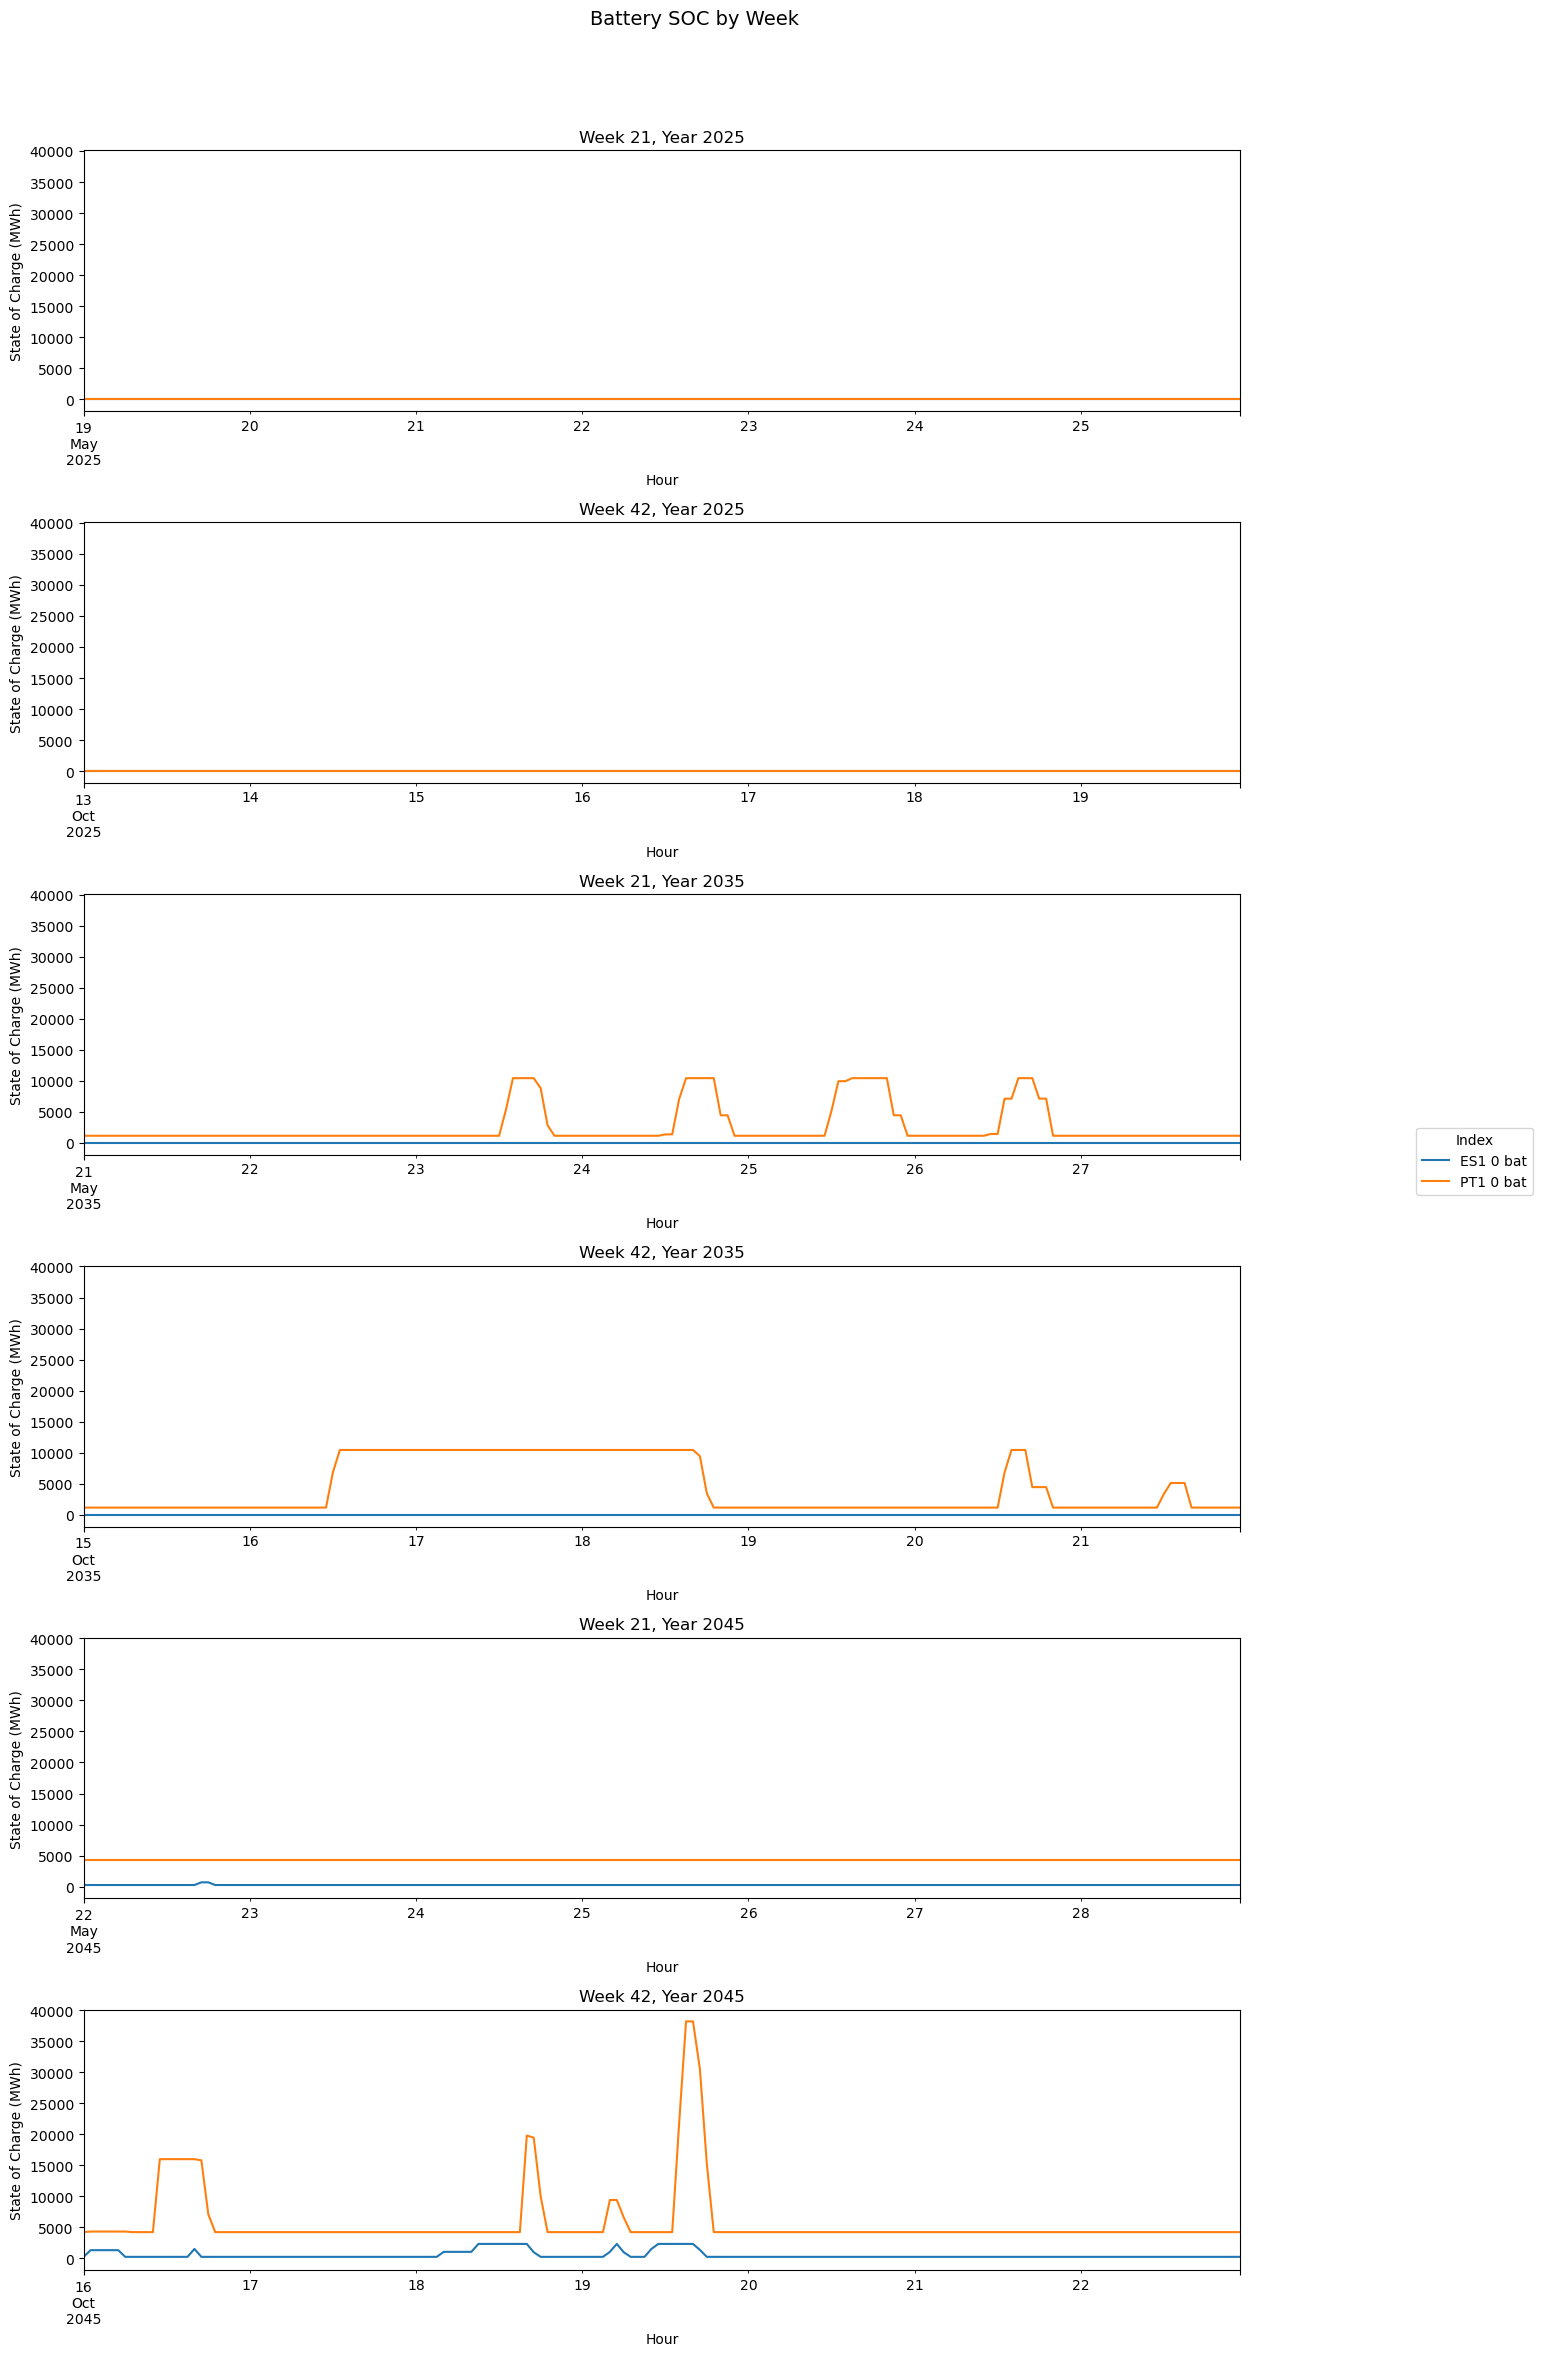

In [27]:
plot_by_week(
    all_decision_variables,
    scenario="37_v1a_multi_weeks_small",
    dataframe_name="battery_soc",
    # indices_to_plot=["ES1 0 bat"],
    ylabel="State of Charge (MWh)",
    title="Battery SOC by Week",
)

In [28]:
def summarize_total_generation_by_carrier(
    all_decision_variables, generators, scenario_names
):
    records = []

    # Mapping: generator index → carrier
    index_to_carrier = generators["carrier"]

    for scenario in scenario_names:
        df = all_decision_variables[scenario]["generation"].copy().reset_index()

        df["year"] = df["datetime"].dt.year
        df["carrier"] = df["index"].map(index_to_carrier)
        df["scenario"] = scenario  # <-- add the scenario column here

        df_grouped = (
            df.groupby(["scenario", "year", "carrier"])["value"].sum().reset_index()
        )
        records.append(df_grouped)

    combined = pd.concat(records, ignore_index=True)

    # Pivot: rows = (scenario, year), columns = carrier types
    pivot = combined.pivot_table(
        index=["scenario", "year"], columns="carrier", values="value", fill_value=0
    )

    return pivot

In [29]:
summary_table = summarize_total_generation_by_carrier(
    all_decision_variables, generators, scenario_names
)
summary_table

carrier                                 CCGT          coal    offwind-ac  \
scenario                  year                                             
128_v1a_multi_weeks       2025  5.136100e+07  1.997217e+07  2.658229e+07   
                          2035  9.486772e+07  2.764434e+07  2.951626e+07   
                          2045  1.441319e+08  3.406911e+07  3.062668e+07   
128_v1a_multi_weeks_small 2025  6.650622e+07  2.485951e+07  2.747163e+07   
                          2035  1.016469e+08  2.820096e+07  3.065576e+07   
                          2045  1.485485e+08  3.394689e+07  3.164648e+07   
37_v1a_multi_weeks        2025  4.922231e+07  1.975187e+07  2.851221e+07   
                          2035  7.834761e+07  2.310907e+07  3.308195e+07   
                          2045  1.269121e+08  2.996704e+07  3.517206e+07   
37_v1a_multi_weeks_small  2025  6.718676e+07  2.657504e+07  2.258843e+07   
                          2035  1.110904e+08  3.231215e+07  2.365320e+07   
                          2045  1.699875e+08  3.699885e+07  2.396499e+07   

carrier                               onwind           ror         solar  
scenario                  year                                            
128_v1a_multi_weeks       2025  4.580657e+07  8.774454e+06  1.992180e+07  
                          2035  4.924968e+07  8.774454e+06  1.992180e+07  
                          2045  5.256865e+07  8.774454e+06  1.992180e+07  
128_v1a_multi_weeks_small 2025  4.877864e+07  1.048377e+07  2.034717e+07  
                          2035  5.148074e+07  1.048377e+07  2.035763e+07  
                          2045  5.416093e+07  1.048377e+07  2.035763e+07  
37_v1a_multi_weeks        2025  6.087742e+07  1.276940e+07  1.719818e+07  
                          2035  6.174950e+07  1.276940e+07  1.719818e+07  
                          2045  6.828788e+07  1.276940e+07  1.719818e+07  
37_v1a_multi_weeks_small  2025  3.505480e+07  4.195184e+06  2.036952e+07  
                          2035  3.720639e+07  4.195184e+06  2.036952e+07  
                          2045  3.734037e+07  4.195184e+06  2.036952e+07

In [30]:
years = (
    all_decision_variables["37_v1a_multi_weeks"]["generation"]
    .index.get_level_values("datetime")
    .year.unique()
)

In [31]:
weeks = (
    all_decision_variables["37_v1a_multi_weeks"]["generation"]
    .index.get_level_values("datetime")
    .unique()
    .isocalendar()
    .week.unique()
)

In [32]:
len(
    all_decision_variables["37_v1a_multi_weeks"]["generation"]
    .index.get_level_values("datetime")
    .unique()
) / (len(years) * len(weeks))

168.0

In [33]:
len(weeks)

4

In [34]:
len(
    all_decision_variables["37_v1a_multi_weeks"]["generation"]
    .index.get_level_values("datetime")
    .unique()
)

2016

In [35]:
def plot_grouped_generation_by_carrier(summary_table, scenario_names):
    df = summary_table.reset_index()

    # Get unique years and carriers
    years = sorted(df["year"].unique())
    carriers = df.columns.difference(["scenario", "year"])
    n_years = len(years)
    n_scenarios = len(scenario_names)

    # Calculate x-axis positions
    positions = []
    labels = []
    for year_idx, year in enumerate(years):
        for scenario_idx in range(n_scenarios):
            positions.append(year_idx * (n_scenarios + 1) + scenario_idx)
            labels.append(f"{year}\n({scenario_idx+1})")

    # Setup bar data
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.8

    # Initialize zeros for stacking
    bottoms = [0] * (n_years * n_scenarios)

    for carrier in carriers:
        heights = []

        for year in years:
            for scenario in scenario_names:
                row = df[(df["scenario"] == scenario) & (df["year"] == year)]
                value = row[carrier].values[0] if not row.empty else 0
                heights.append(value)

        ax.bar(
            positions,
            heights,
            bar_width,
            bottom=bottoms,
            label=carrier,
        )
        bottoms = [b + h for b, h in zip(bottoms, heights)]

    # Format axis
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Year (Scenario Number)", fontsize=12)
    ax.set_ylabel("Total Generation (MWh)", fontsize=12)
    ax.set_title("Generation by Carrier Type Across Scenarios and Years", fontsize=14)

    # Scenario legend
    scenario_legend = "\n".join(
        [f"{i+1}: {name}" for i, name in enumerate(scenario_names)]
    )
    plt.gcf().text(
        0.99,
        0.01,
        scenario_legend,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    )

    ax.legend(title="Carrier", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    plt.show()

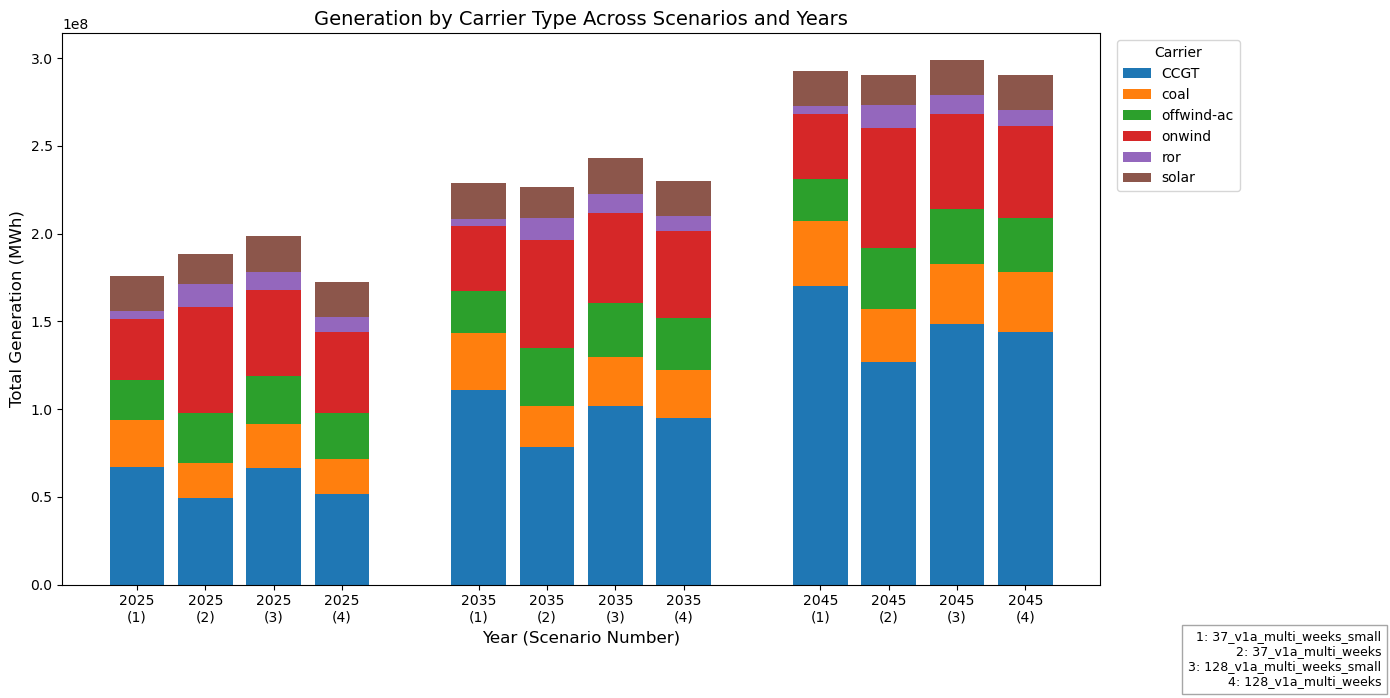

In [36]:
summary_table = summarize_total_generation_by_carrier(
    all_decision_variables, generators, scenario_names
)

plot_grouped_generation_by_carrier(summary_table, scenario_names)

In [37]:
def plot_grouped_battery_discharge(all_decision_variables, scenario_names):
    combined_df = []

    for scenario in scenario_names:
        df = all_decision_variables[scenario]["battery_discharging"].reset_index()
        df["year"] = df["datetime"].dt.year
        df_grouped = df.groupby("year", as_index=False)["value"].sum()
        df_grouped["scenario"] = scenario
        combined_df.append(df_grouped)

    combined_df = pd.concat(combined_df, ignore_index=True)

    # Unique years and scenarios
    years = sorted(combined_df["year"].unique())
    n_years = len(years)
    n_scenarios = len(scenario_names)

    # Explicit x-positions and labels for clarity
    positions = []
    labels = []

    for year_idx, year in enumerate(years):
        for scenario_idx, scenario in enumerate(scenario_names):
            positions.append(year_idx * (n_scenarios + 1) + scenario_idx)
            labels.append(f"{year}\n({scenario_idx+1})")

    # Plot setup
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.8

    for i, scenario in enumerate(scenario_names):
        scenario_df = combined_df[combined_df["scenario"] == scenario]
        scenario_values = (
            scenario_df.set_index("year").reindex(years)["value"].fillna(0)
        )

        bar_positions = [
            year_idx * (n_scenarios + 1) + i for year_idx in range(n_years)
        ]
        ax.bar(
            bar_positions,
            scenario_values,
            bar_width,
            label=f"Scenario {i+1}",
            alpha=0.75,
        )

    # Set xticks explicitly
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=10)

    # Set labels and formatting
    ax.set_xlabel("Year (Scenario Number)", fontsize=12)
    ax.set_ylabel("Total Battery Discharge (MWh)", fontsize=12)
    ax.set_title("Battery Discharge Across Scenarios and Years", fontsize=14)

    # Scenario legend
    scenario_legend = "\n".join(
        [f"{i+1}: {name}" for i, name in enumerate(scenario_names)]
    )
    plt.gcf().text(
        0.99,
        0.01,
        scenario_legend,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    )

    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    plt.legend(title="Scenario", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.show()

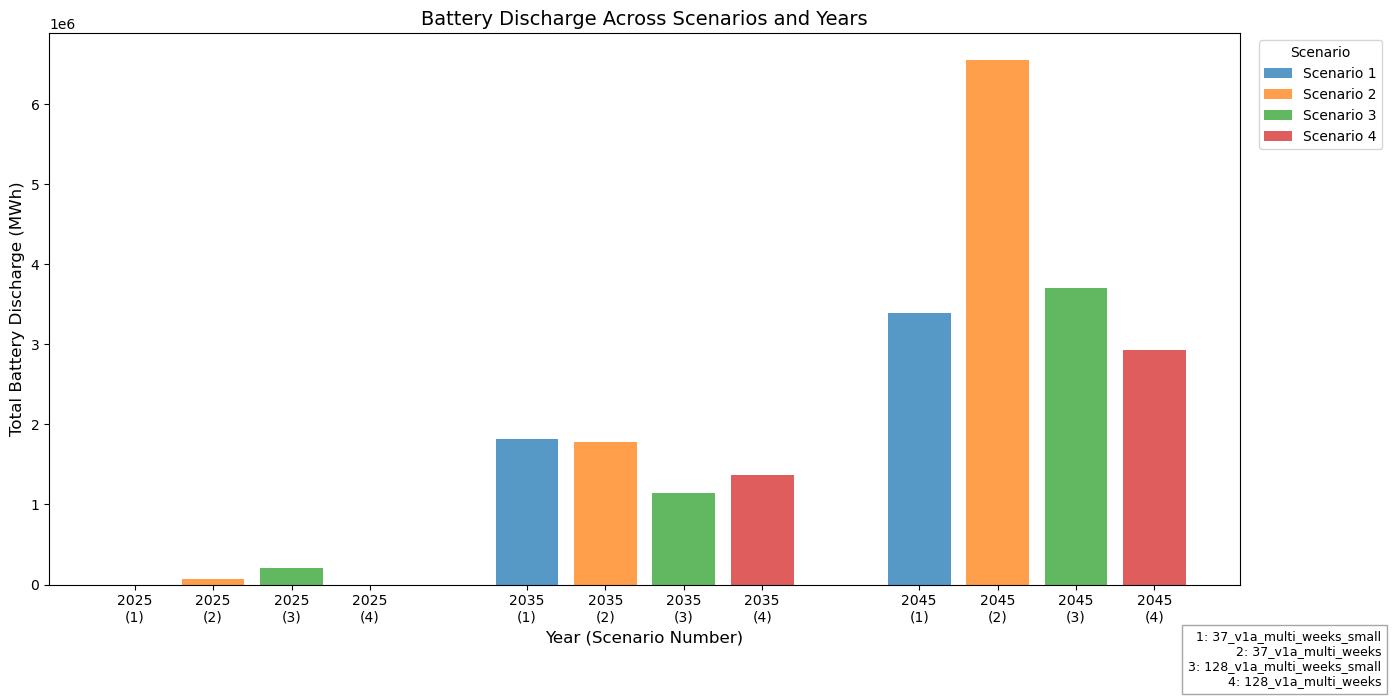

In [38]:
plot_grouped_battery_discharge(all_decision_variables, scenario_names)

In [39]:
def plot_grouped_battery_charging(all_decision_variables, scenario_names):
    combined_df = []

    for scenario in scenario_names:
        df = all_decision_variables[scenario]["battery_charging"].reset_index()
        df["year"] = df["datetime"].dt.year
        df_grouped = df.groupby("year", as_index=False)["value"].sum()
        df_grouped["scenario"] = scenario
        combined_df.append(df_grouped)

    combined_df = pd.concat(combined_df, ignore_index=True)

    # Unique years and scenarios
    years = sorted(combined_df["year"].unique())
    n_years = len(years)
    n_scenarios = len(scenario_names)

    # X-axis positions and labels
    positions = []
    labels = []
    for year_idx, year in enumerate(years):
        for scenario_idx, _ in enumerate(scenario_names):
            positions.append(year_idx * (n_scenarios + 1) + scenario_idx)
            labels.append(f"{year}\n({scenario_idx+1})")

    # Plot setup
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.8

    for i, scenario in enumerate(scenario_names):
        scenario_df = combined_df[combined_df["scenario"] == scenario]
        scenario_values = (
            scenario_df.set_index("year").reindex(years)["value"].fillna(0)
        )

        bar_positions = [
            year_idx * (n_scenarios + 1) + i for year_idx in range(n_years)
        ]
        ax.bar(
            bar_positions,
            scenario_values,
            bar_width,
            label=f"Scenario {i+1}",
            alpha=0.75,
        )

    # Axis labels and ticks
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Year (Scenario Number)", fontsize=12)
    ax.set_ylabel("Total Battery Charging (MWh)", fontsize=12)
    ax.set_title("Battery Charging Across Scenarios and Years", fontsize=14)

    # Scenario legend
    scenario_legend = "\n".join(
        [f"{i+1}: {name}" for i, name in enumerate(scenario_names)]
    )
    plt.gcf().text(
        0.99,
        0.01,
        scenario_legend,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    )

    ax.legend(title="Scenario", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    plt.show()

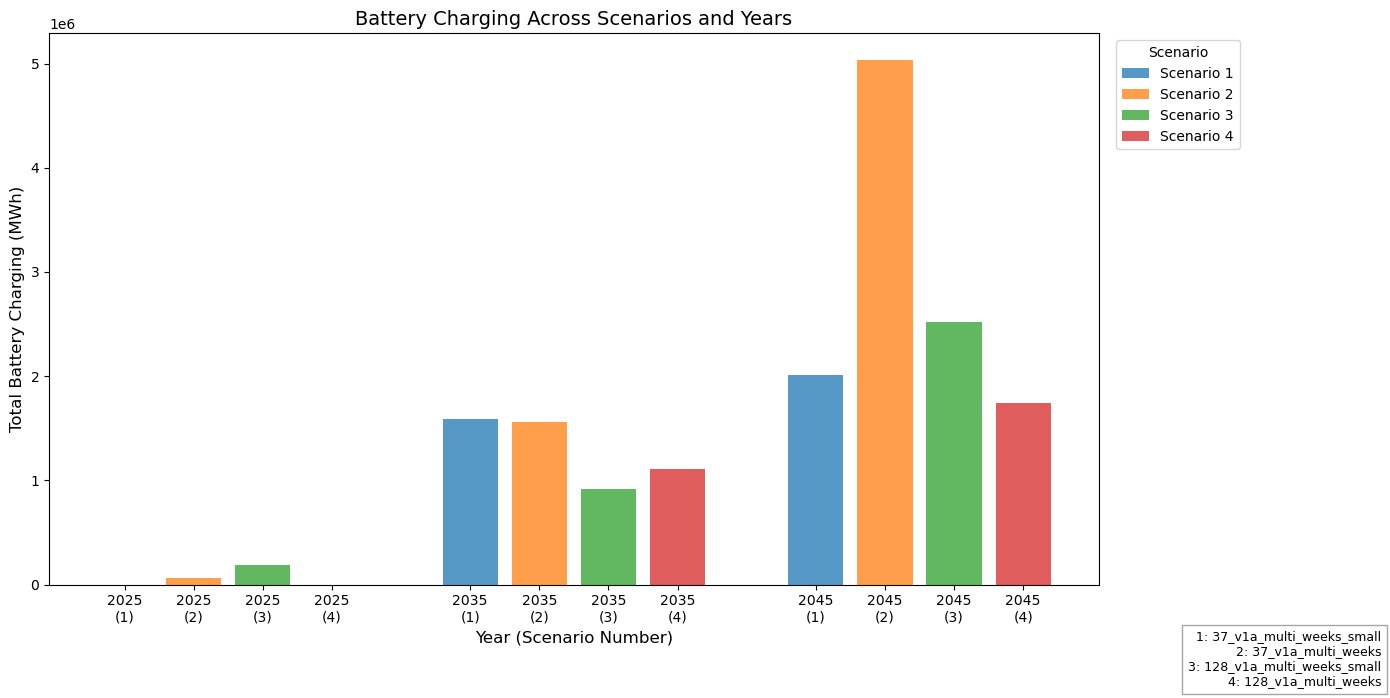

In [40]:
plot_grouped_battery_charging(all_decision_variables, scenario_names)

In [41]:
def plot_grouped_load_shedding(all_decision_variables, scenario_names):
    combined_df = []

    for scenario in scenario_names:
        df = all_decision_variables[scenario]["load_shedding"].reset_index()
        df["year"] = df["datetime"].dt.year
        df_grouped = df.groupby("year", as_index=False)["value"].sum()
        df_grouped["scenario"] = scenario
        combined_df.append(df_grouped)

    combined_df = pd.concat(combined_df, ignore_index=True)

    # Unique years and scenarios
    years = sorted(combined_df["year"].unique())
    n_years = len(years)
    n_scenarios = len(scenario_names)

    # X-axis positions and labels
    positions = []
    labels = []
    for year_idx, year in enumerate(years):
        for scenario_idx, _ in enumerate(scenario_names):
            positions.append(year_idx * (n_scenarios + 1) + scenario_idx)
            labels.append(f"{year}\n({scenario_idx+1})")

    # Plot setup
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.8

    for i, scenario in enumerate(scenario_names):
        scenario_df = combined_df[combined_df["scenario"] == scenario]
        scenario_values = (
            scenario_df.set_index("year").reindex(years)["value"].fillna(0)
        )

        bar_positions = [
            year_idx * (n_scenarios + 1) + i for year_idx in range(n_years)
        ]
        ax.bar(
            bar_positions,
            scenario_values,
            bar_width,
            label=f"Scenario {i+1}",
            alpha=0.75,
            color="crimson" if scenario_values.sum() > 0 else "grey",
        )

    # Axis labels and ticks
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Year (Scenario Number)", fontsize=12)
    ax.set_ylabel("Total Load Shedding (MWh)", fontsize=12)
    ax.set_title("Load Shedding Across Scenarios and Years", fontsize=14)

    # Scenario legend
    scenario_legend = "\n".join(
        [f"{i+1}: {name}" for i, name in enumerate(scenario_names)]
    )
    plt.gcf().text(
        0.99,
        0.01,
        scenario_legend,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    )

    ax.legend(title="Scenario", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    plt.show()

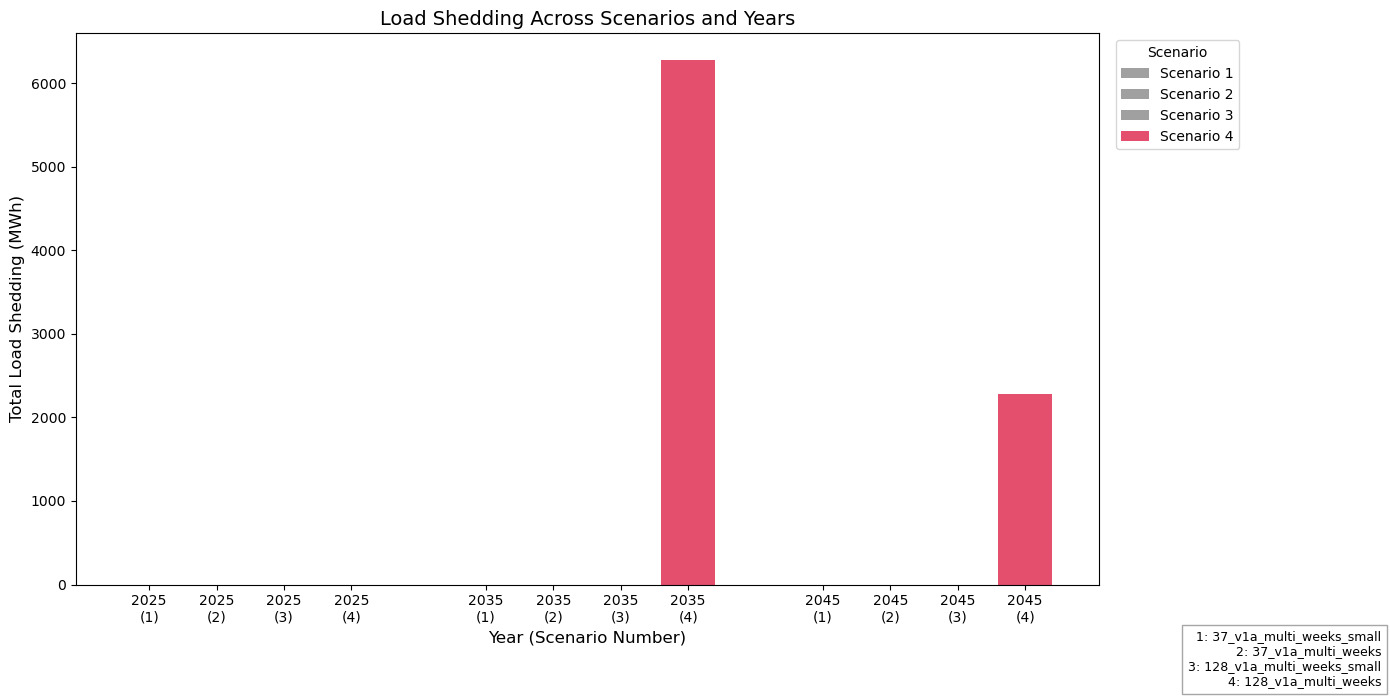

In [42]:
plot_grouped_load_shedding(all_decision_variables, scenario_names)

In [43]:
def plot_grouped_curtailment(all_decision_variables, scenario_names):
    combined_df = []

    for scenario in scenario_names:
        df = all_decision_variables[scenario]["curtailment"].reset_index()
        df["year"] = df["datetime"].dt.year
        df_grouped = df.groupby("year", as_index=False)["value"].sum()
        df_grouped["scenario"] = scenario
        combined_df.append(df_grouped)

    combined_df = pd.concat(combined_df, ignore_index=True)

    # Unique years and scenarios
    years = sorted(combined_df["year"].unique())
    n_years = len(years)
    n_scenarios = len(scenario_names)

    # X-axis positions and labels
    positions = []
    labels = []
    for year_idx, year in enumerate(years):
        for scenario_idx, _ in enumerate(scenario_names):
            positions.append(year_idx * (n_scenarios + 1) + scenario_idx)
            labels.append(f"{year}\n({scenario_idx+1})")

    # Plot setup
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.8

    for i, scenario in enumerate(scenario_names):
        scenario_df = combined_df[combined_df["scenario"] == scenario]
        scenario_values = (
            scenario_df.set_index("year").reindex(years)["value"].fillna(0)
        )

        bar_positions = [
            year_idx * (n_scenarios + 1) + i for year_idx in range(n_years)
        ]
        ax.bar(
            bar_positions,
            scenario_values,
            bar_width,
            label=f"Scenario {i+1}",
            alpha=0.75,
            color="darkorange",
        )

    # Axis labels and ticks
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Year (Scenario Number)", fontsize=12)
    ax.set_ylabel("Total Curtailment (MWh)", fontsize=12)
    ax.set_title("Curtailment Across Scenarios and Years", fontsize=14)

    # Scenario legend
    scenario_legend = "\n".join(
        [f"{i+1}: {name}" for i, name in enumerate(scenario_names)]
    )
    plt.gcf().text(
        0.99,
        0.01,
        scenario_legend,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    )

    ax.legend(title="Scenario", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    plt.show()

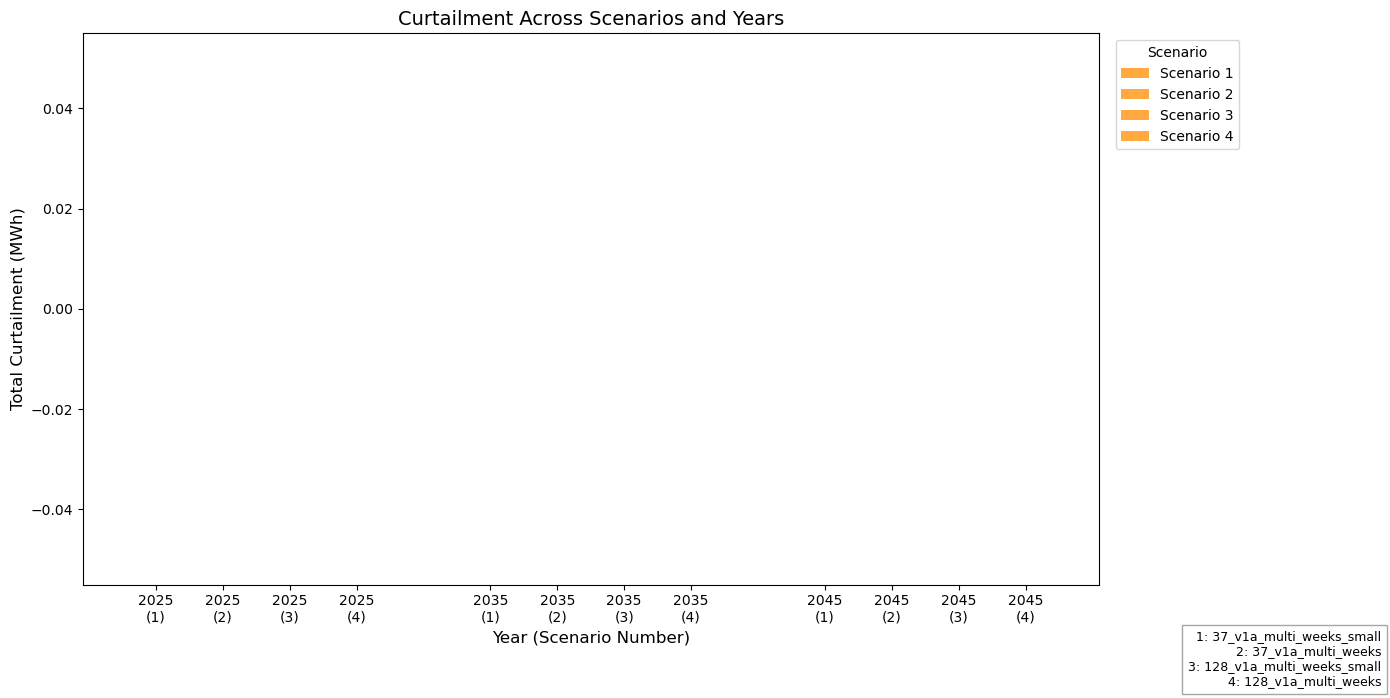

In [44]:
plot_grouped_curtailment(all_decision_variables, scenario_names)

In [45]:
def plot_grouped_power_flow(all_decision_variables, scenario_names):
    combined_df = []

    for scenario in scenario_names:
        df = all_decision_variables[scenario]["power_flow"].reset_index()
        df["year"] = df["datetime"].dt.year
        df["abs_flow"] = df["value"].abs()  # Use absolute value of flow

        df_grouped = df.groupby("year", as_index=False)["abs_flow"].sum()
        df_grouped["scenario"] = scenario
        combined_df.append(df_grouped)

    combined_df = pd.concat(combined_df, ignore_index=True)

    # Unique years and scenarios
    years = sorted(combined_df["year"].unique())
    n_years = len(years)
    n_scenarios = len(scenario_names)

    # X-axis positions and labels
    positions = []
    labels = []
    for year_idx, year in enumerate(years):
        for scenario_idx, _ in enumerate(scenario_names):
            positions.append(year_idx * (n_scenarios + 1) + scenario_idx)
            labels.append(f"{year}\n({scenario_idx+1})")

    # Plot setup
    fig, ax = plt.subplots(figsize=(14, 7))
    bar_width = 0.8

    for i, scenario in enumerate(scenario_names):
        scenario_df = combined_df[combined_df["scenario"] == scenario]
        scenario_values = (
            scenario_df.set_index("year").reindex(years)["abs_flow"].fillna(0)
        )

        bar_positions = [
            year_idx * (n_scenarios + 1) + i for year_idx in range(n_years)
        ]
        ax.bar(
            bar_positions,
            scenario_values,
            bar_width,
            label=f"Scenario {i+1}",
            alpha=0.75,
            color="steelblue",
        )

    # Axis labels and ticks
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_xlabel("Year (Scenario Number)", fontsize=12)
    ax.set_ylabel("Total Power Flow (MWh)", fontsize=12)
    ax.set_title(
        "Cumulative Transmission Usage Across Scenarios and Years", fontsize=14
    )

    # Scenario legend
    scenario_legend = "\n".join(
        [f"{i+1}: {name}" for i, name in enumerate(scenario_names)]
    )
    plt.gcf().text(
        0.99,
        0.01,
        scenario_legend,
        fontsize=9,
        ha="right",
        va="bottom",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    )

    ax.legend(title="Scenario", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout(rect=[0, 0.05, 0.9, 1])
    plt.show()

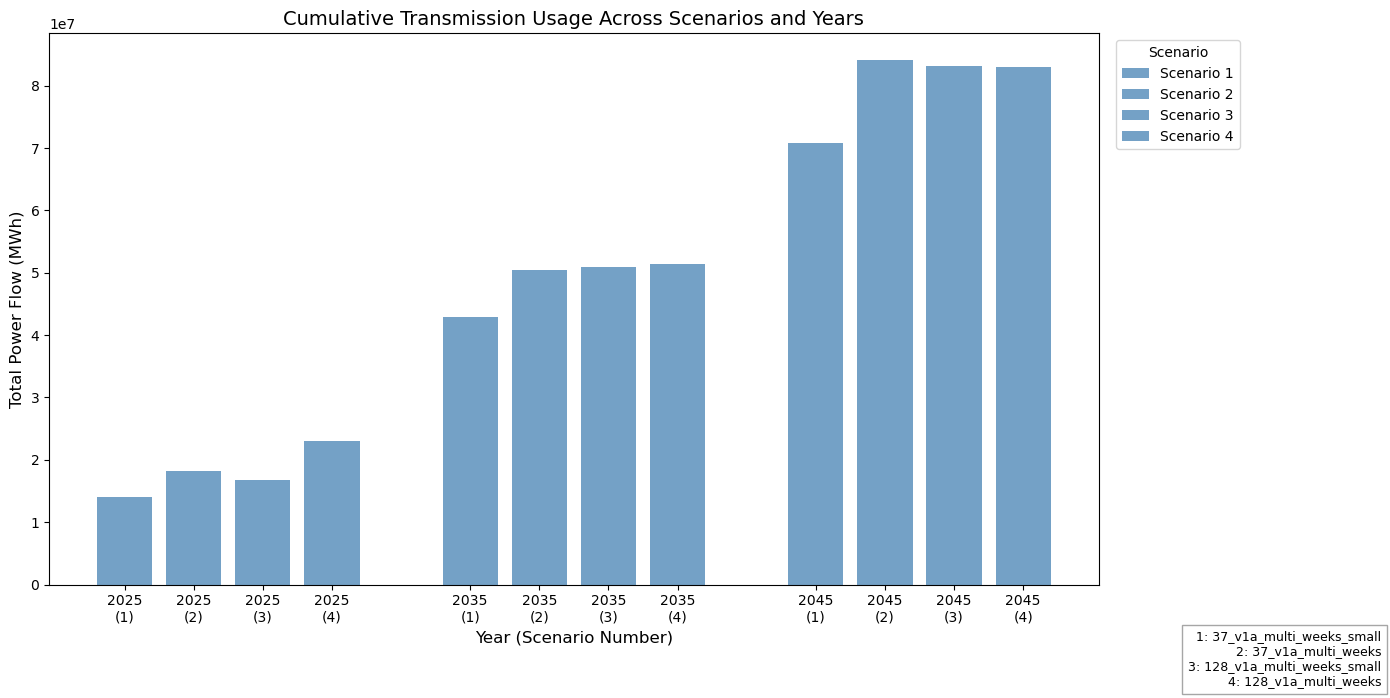

In [46]:
plot_grouped_power_flow(all_decision_variables, scenario_names)

## Runtime and macro results

In [47]:
def read_macro_results_from_mapped_folders(folders, names):
    macro_results = []

    for folder, scenario_name in zip(folders, names):
        path = os.path.join(folder, "model_info", "model_info.csv")
        df = pd.read_csv(path)

        # Drop any completely empty rows and get the first valid one
        df = df.dropna(how="all").iloc[0]

        df.name = scenario_name  # set row name as scenario
        macro_results.append(df)

    # Combine all into one DataFrame
    macro_df = pd.DataFrame(macro_results)
    macro_df.index.name = "model"

    return macro_df

In [48]:
folders = [os.path.join(batch_folder, folder) for folder in os.listdir(batch_folder)]
names = [
    "37_v1a_multi_weeks_small",
    "37_v1a_multi_weeks",
    "128_v1a_multi_weeks_small",
    "128_v1a_multi_weeks",
]

macro_results_df = read_macro_results_from_mapped_folders(folders, names)

In [49]:
macro_results_df

,Objective Value,Optimality Gap (%),Runtime (s),Build Time (s),Optimize Time (s),Total Time (s),Number of Variables,Number of Constraints,Number of Nonzeros,Number of Integer Variables,Number of Binary Variables,Number of Quadratic Constraints,Model Status
model,,,,,,,,,,,,,
37_v1a_multi_weeks_small,1.057093e+10,NaN,3.897856,6.565981,3.983920,10.549901,54516.0,62586.0,163473.0,0.0,0.0,0.0,2.0
37_v1a_multi_weeks,8.868062e+09,NaN,1.742063,10.779186,1.781105,12.560290,108948.0,125094.0,326613.0,0.0,0.0,0.0,2.0
128_v1a_multi_weeks_small,9.782901e+09,NaN,21.784843,21.564784,21.868522,43.433306,217812.0,250110.0,653178.0,0.0,0.0,0.0,2.0
128_v1a_multi_weeks,1.011896e+10,NaN,68.131074,43.172924,68.280988,111.453912,435540.0,500142.0,1306353.0,0.0,0.0,0.0,2.0


In [50]:
def plot_macro_runtime(macro_df):
    df = macro_df.copy()
    df[["Build Time (s)", "Optimize Time (s)"]] = df[
        ["Build Time (s)", "Optimize Time (s)"]
    ].astype(float)

    ax = df[["Build Time (s)", "Optimize Time (s)"]].plot(
        kind="bar", stacked=True, figsize=(12, 6), color=["skyblue", "darkblue"]
    )
    ax.set_ylabel("Runtime (seconds)")
    ax.set_xlabel("Model")
    ax.set_title("Total Runtime per Model (Stacked: Build + Optimize)")
    ax.legend(title="Phase")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_macro_objective_value(macro_df):
    df = macro_df.copy()
    df["Objective Value"] = df["Objective Value"].astype(float)

    ax = df["Objective Value"].plot(kind="bar", figsize=(10, 5), color="mediumseagreen")
    ax.set_ylabel("Objective Value")
    ax.set_xlabel("Model")
    ax.set_title("Objective Value per Model")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_macro_model_size(macro_df):
    df = macro_df.copy()
    cols = [
        "Number of Variables",
        "Number of Constraints",
        "Number of Nonzeros",
        "Number of Integer Variables",
        "Number of Binary Variables",
    ]
    df[cols] = df[cols].astype(float)

    ax = df[cols].plot(kind="bar", figsize=(14, 6), colormap="tab10")
    ax.set_ylabel("Count")
    ax.set_xlabel("Model")
    ax.set_title("Model Size: Variables, Constraints, etc. per Model")
    ax.legend(title="Metric", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

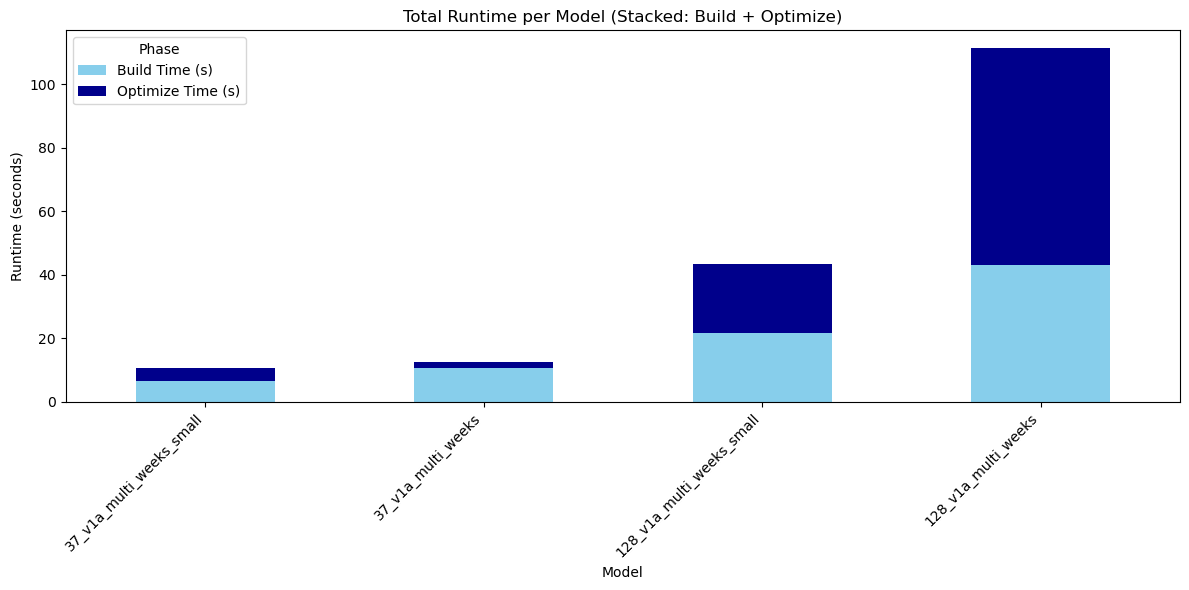

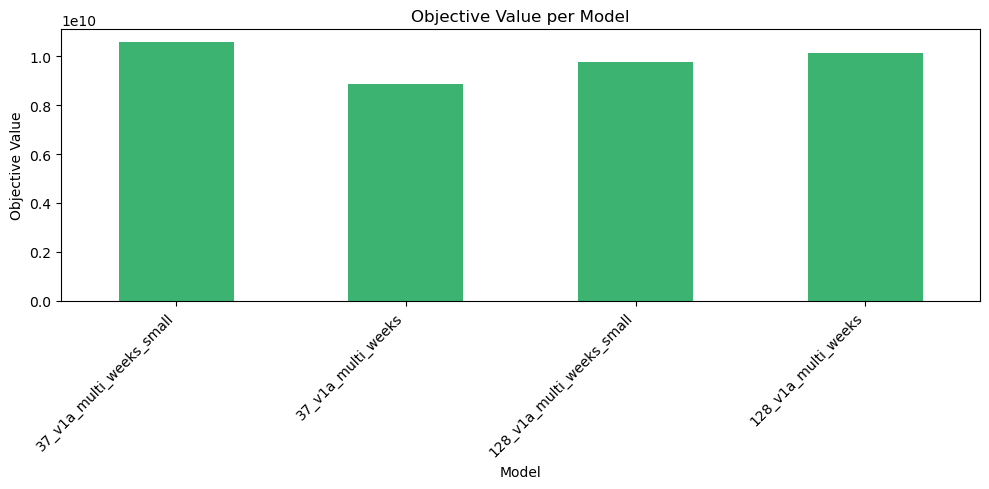

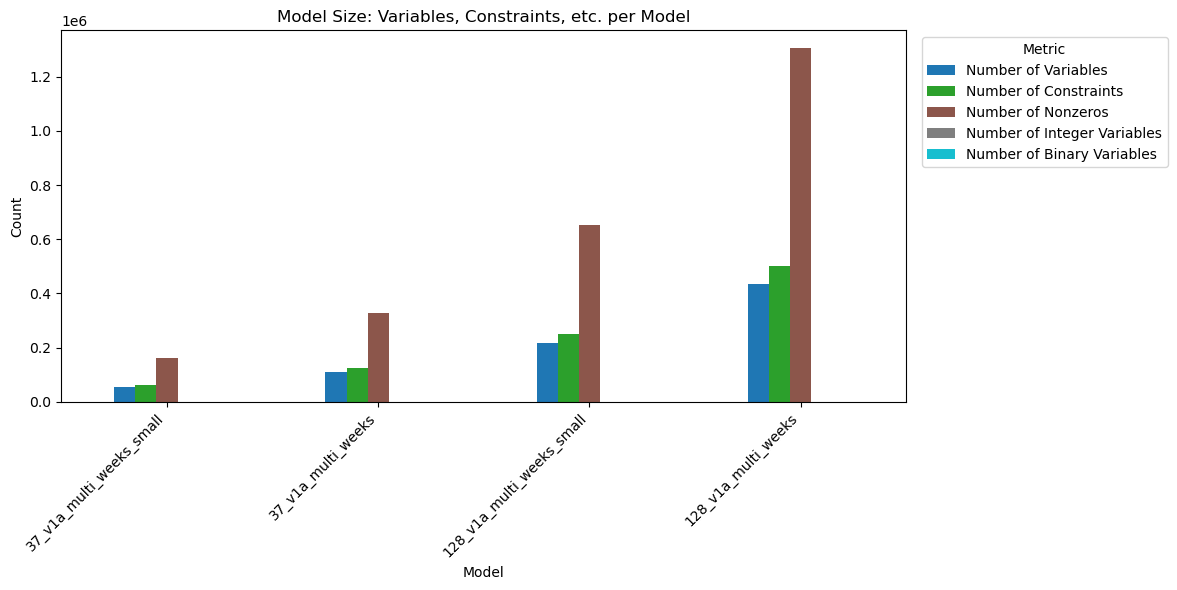

In [51]:
# --- Example Calls ---
plot_macro_runtime(macro_results_df)
plot_macro_objective_value(macro_results_df)
plot_macro_model_size(macro_results_df)

In [52]:
def plot_macro_size_vs_runtime(macro_df):
    df = macro_df.copy()
    size_cols = ["Number of Variables", "Number of Constraints", "Number of Nonzeros"]
    df[size_cols + ["Optimize Time (s)"]] = df[
        size_cols + ["Optimize Time (s)"]
    ].astype(float)

    fig, ax1 = plt.subplots(figsize=(14, 6))

    df[size_cols].plot(kind="bar", ax=ax1, colormap="tab10")
    ax1.set_ylabel("Model Size (Count)")
    ax1.set_xlabel("Model")
    ax1.set_title("Model Size and Optimize Time per Model")
    ax1.legend(title="Model Size", bbox_to_anchor=(1.01, 1), loc="upper left")

    ax2 = ax1.twinx()
    ax2.plot(
        df.index,
        df["Optimize Time (s)"],
        color="black",
        marker="o",
        linewidth=2,
        label="Optimize Time (s)",
    )
    ax2.set_ylabel("Optimize Time (seconds)")
    ax2.legend(loc="upper right")

    ax1.set_xticks(range(len(df.index)))
    ax1.set_xticklabels(df.index, rotation=45, ha="right")

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

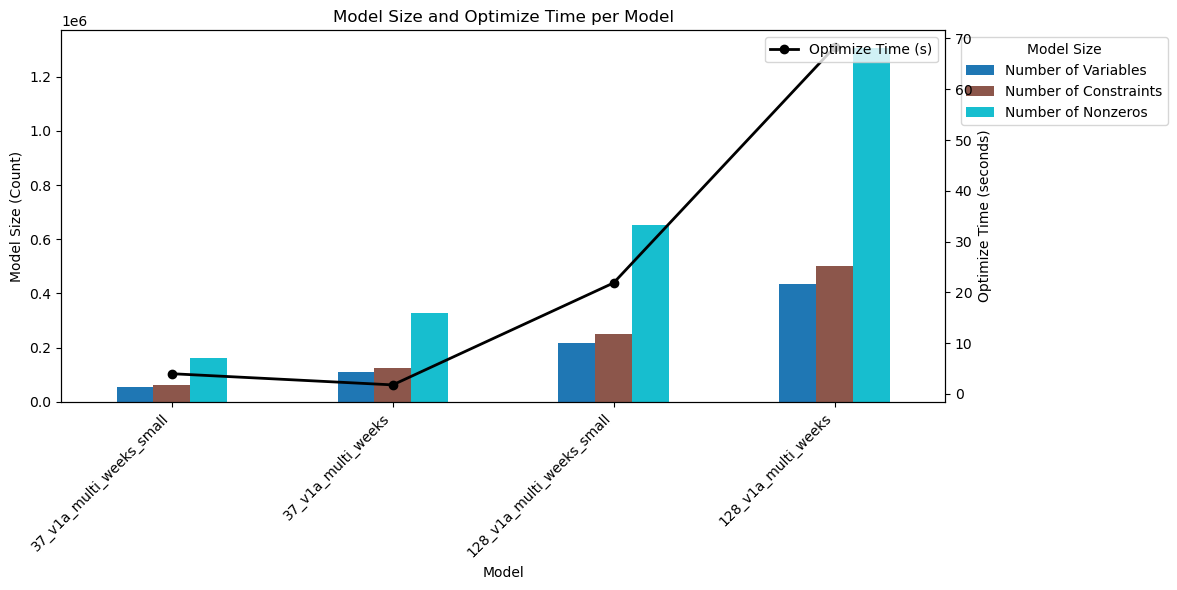

In [53]:
plot_macro_size_vs_runtime(macro_results_df)